<h1 style="text-align: center;">Deep Learning Project</h1>

** **

## <p style="text-align: center;"><i>02 - Pre-Processing </i></p>

** **
<p style="text-align: center;">
David Cascão - 20240851 <br>
Jan-Louis Schneider - 20240506 <br>
Emir Kamiloglu - 20240945 <br>
Marta Boavida - 20240519 <br>
Sofia Gomes - 20240848
</p>


## <span style="color:#FF007F">  Notebook  </span> 

# <span style="color:yellow">  ACABAR  </span> 

In this notebook, 


## <span style="color:#FF007F"> Table of Contents </span>

<a class="anchor" id="top"></a>

1. [Import Libraries](#one-bullet) <br>

2. [Import Datasets](#two-bullet) <br>

   2.1 [Create a Small Sample from the Training Set](#two-one-bullet) <br>

   2.2 [Extracted Feature DataFrame (features_df)](#two-two-bullet) <br>

3. [Visualizations](#three-bullet) <br>

   3.1 [Boxplots of RGB and HSV Features per Class](#three-one-bullet) <br>

   3.2 [RGB Channels](#three-two-bullet) <br>

   3.3 [HSV Features](#three-three-bullet) <br>

   3.4 [Image Quality Metrics: Sharpness](#three-four-bullet) <br>

   3.5 [Visualizing Extremes in Sharpness](#three-five-bullet) <br>

   3.6 [Shape Analysis: Morphological Features](#three-six-bullet) <br>

   3.7 [Shape Extremes](#three-seven-bullet) <br>

   3.8 [Foreground Composition: Animal-to-Background Ratio](#three-eight-bullet) <br>

   3.9 [Foreground Ratio Extremes](#three-nine-bullet) <br>

4. [CLIP-Based Image Filtering](#four-bullet) <br>

   4.1 [Reclassify Non-Animal Samples Using CLIP Predictions](#four-one-bullet) <br>
   
   4.2 [Class Distribution](#four-two-bullet) <br>
   
5. [Augmentation as a Data Balancer](#five-bullet) <br>

   


<a class="anchor" id="one-bullet"></a>

## <span style="color:#FF007F"> 1. Import Libraries</span>

<a href="#top">Top &#129033;</a>

The first step is to install some necessary packages and pretrained models.

In [23]:
# Uninstall potential conflicts
!pip uninstall -y clip torchvision

# Install CLIP and dependencies
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

# Install other requirements
!pip install rembg[gpu] pillow matplotlib torch torchvision pandas numpy opencv-python

# For data loading and augmentation
!pip install albumentations


Found existing installation: clip 1.0
Uninstalling clip-1.0:
  Successfully uninstalled clip-1.0
Found existing installation: torchvision 0.21.0
Uninstalling torchvision-0.21.0:
  Successfully uninstalled torchvision-0.21.0


  Cloning https://github.com/openai/CLIP.git to c:\users\asus.laptop-sfdpa4g4\appdata\local\temp\pip-req-build-rxbrwxma
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached torchvision-0.21.0-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
Using cached torchvision-0.21.0-cp312-cp312-win_amd64.whl (1.6 MB)
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369594 sha256=804229e76e43eb53e5ca486ab8000e94cb19f58642d7534b324c72ecdba2e267
  Stored in directory: C:\Users\ASUS.LAPTOP-SFDPA4G4\AppData\Local\Temp\pip-ephem-wheel-cache-0cged92b\wheels\35\3e\df\3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\ASUS.LAPTOP-SFDPA4G4\AppData\Local\Temp\pip-req-build-rxbrwxma'


In [24]:
import os
import clip
import torch
import pandas as pd
import numpy as np
from PIL import Image
import cv2
from torchvision import transforms
from rembg import remove
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
import PIL.Image
from collections import defaultdict
PIL.Image.MAX_IMAGE_PIXELS = 115600000 * 2  # Double the current limit

<a class="anchor" id="two-bullet"> 

## <span style="color:#FF007F"> 2. Import Datasets</span> 

<a href="#top">Top &#129033;</a>

Next, we start by importing the dataset.

In [ ]:
# Load CSV files
train_df = pd.read_csv("../data/train_df.csv")
val_df = pd.read_csv("../data/val_df.csv")
test_df = pd.read_csv("../data/test_df.csv")

# Function to create image paths by joining with base directory
def get_image_paths(df, base_dir="../data"):
    return [os.path.join(base_dir, img_path) for img_path in df["file_path"].values]

# Create your requested variables

train_paths = get_image_paths(train_df)
val_paths = get_image_paths(val_df)
test_paths = get_image_paths(test_df)

# Verify
print(f"Training images: {len(train_paths)}")
print(f"Validation images: {len(val_paths)}")
print(f"Test images: {len(test_paths)}")
print("\nSample paths:")
print(train_paths[:3])

Training images: 8388
Validation images: 1797
Test images: 1798

Sample paths:
['../data\\chordata_ranidae/21985147_2920193_eol-full-size-copy.jpg', '../data\\chordata_bufonidae/14130545_332433_eol-full-size-copy.jpg', '../data\\cnidaria_agariciidae/21699220_45276518_eol-full-size-copy.jpg']


The following code displays a random sample of 10 images from the training set. This is useful to inspect the visual diversity of the dataset, identify potential noise (such as sketches, maps, or mislabeled images), and better understand the challenges posed by visually ambiguous samples (e.g., camouflaged or zoomed-out animals).

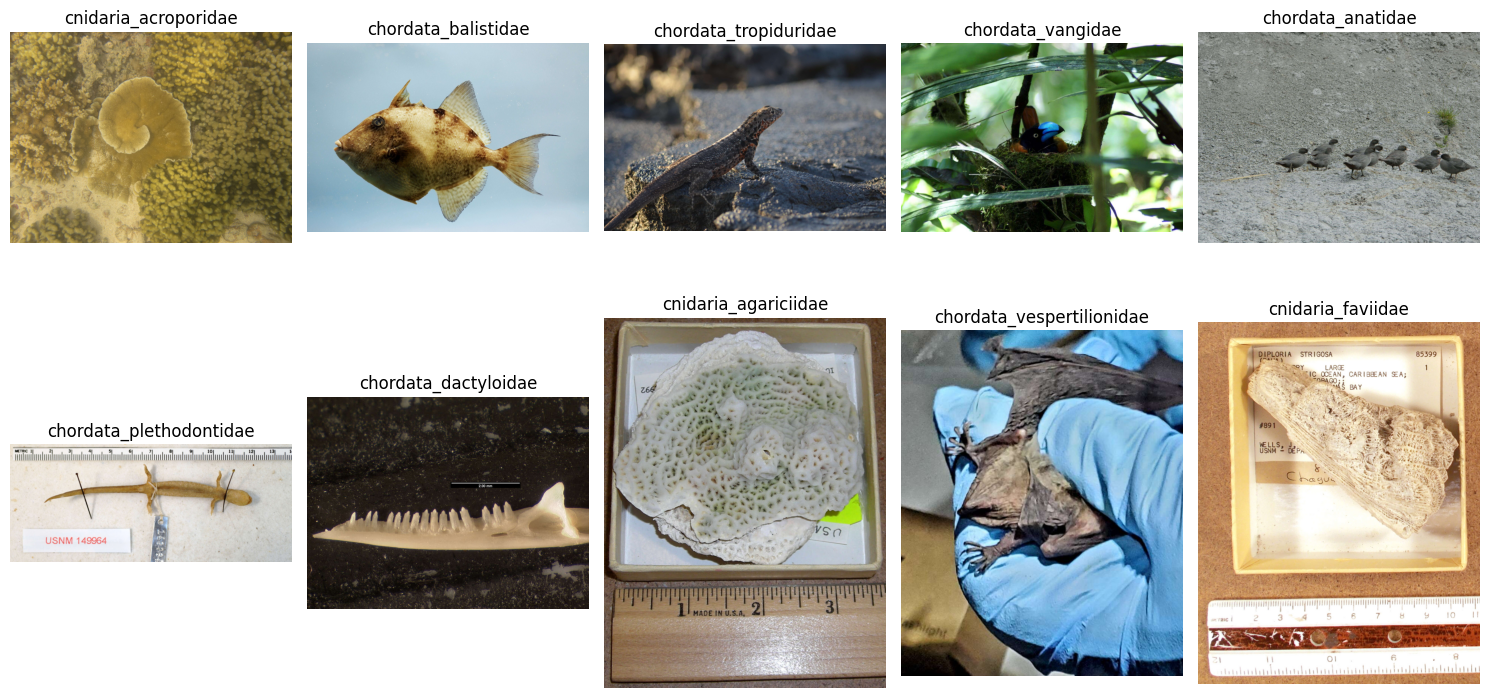

In [ ]:
# Set up the plot
plt.figure(figsize=(15, 8))

# Randomly select 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Plot each image
for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    label =  train_df.iloc[idx]["phylum"] +"_"+ train_df.iloc[idx]["family"] 
    
    # Load image
    img = Image.open(img_path)
    
    # Create subplot
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(f"{label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

<a class="anchor" id="two-one-bullet"></a>

### 2.1 Create a Small Sample from the Training Set

<a href="#top">Top &#129033;</a>

To work with a smaller, more manageable subset of the training data (useful for quick experiments or visualization), this snippet randomly selects 1% of the full dataset.

In [27]:
sample_df = train_df.sample(frac=0.01, random_state=42).reset_index(drop=True)
sample_paths = get_image_paths(sample_df)

<a class="anchor" id="two-two-bullet"></a>

### 2.2 Extracted Feature DataFrame (features_df)

<a href="#top">Top &#129033;</a>

This section sets up the feature extraction process and functions for analyzing image characteristics such as color, shape, sharpness, and more.



In [ ]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# CONFIGURAÇÃO E FUNÇÕES
# =============================================================================

# Constantes de visualização
LIGHT_COLORS = ["red", "green", "blue"]
HSV_COLORS = ["purple", "orange", "gold"]
SHAPE_COLORS = ["teal", "magenta", "cyan"]
FOREGROUND_COLORS = ["lime", "darkgreen"]
ROWS = 6
BOX_WIDTH = 0.04
SPACING = 0.05
CLASS_SPACING = 0.25

def extract_features(df, data_root="../data/"):
    """Extrai características de imagens com tratamento automático de caminhos"""
    features = []
    for _, row in df.iterrows():
        img_path = f"{data_root}{row["file_path"]}"
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        
        # Propriedades de forma
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU + cv2.THRESH_BINARY_INV)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        main_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(main_contour)
        perimeter = cv2.arcLength(main_contour, True)
        x, y, w, h = cv2.boundingRect(main_contour)
        
        features.append({
            "class": row["phylum"] + "_" + row["family"],
            "path": img_path,
            "red": img[:,:,0].mean(),
            "green": img[:,:,1].mean(),
            "blue": img[:,:,2].mean(),
            "hue": hsv[:,:,0].mean(),
            "saturation": hsv[:,:,1].mean(),
            "sharpness": cv2.Laplacian(gray, cv2.CV_64F).var(),
            "compactness": (perimeter**2)/(4*np.pi*area),
            "aspect_ratio": w/h,
            "foreground_ratio": area / (gray.shape[0]*gray.shape[1])
        })
    return pd.DataFrame(features)

def show_extremes(df, feature):
    """Mostra exemplos extremos para uma característica"""
    fig, axs = plt.subplots(2, 2, figsize=(5, 4))
    extremes = pd.concat([df.nlargest(2, feature), df.nsmallest(2, feature)])
    
    for i, (_, row) in enumerate(extremes.iterrows()):
        ax = axs[i//2, i%2]
        img = cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"{feature}: {row[feature]:.2f}\n{row["class"]}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def plot_feature_distribution(df, features, colors, title, ylim=None):
    """Plota distribuição de características"""
    unique_classes = sorted(df["class"].unique())
    CLASSES_PER_ROW = len(unique_classes) // ROWS

    fig, axes = plt.subplots(ROWS, 1, figsize=(25, ROWS*3))
    fig.patch.set_facecolor("white")

    for row in range(ROWS):
        ax = axes[row] if ROWS > 1 else axes
        ax.set_facecolor("white")

        start_idx = row * CLASSES_PER_ROW
        end_idx = start_idx + CLASSES_PER_ROW
        row_classes = unique_classes[start_idx:end_idx]

        for i, feature in enumerate(features):
            positions = np.arange(len(row_classes)) * CLASS_SPACING + (i-1)*SPACING

            box = ax.boxplot(
                [df[df["class"]==c][feature] for c in row_classes],
                positions=positions,
                widths=BOX_WIDTH,
                patch_artist=True,
                showfliers=True,
                flierprops=dict(
                    marker="o",
                    markerfacecolor=colors[i],
                    markersize=4,
                    markeredgecolor="none",
                    alpha=0.5
                )
            )

            for element in ["boxes", "whiskers", "caps"]:
                plt.setp(box[element], color=colors[i])

            plt.setp(box["boxes"], facecolor=colors[i], alpha=0.4)
            plt.setp(box["medians"], color="black", linewidth=1)

        ax.set_xticks([])
        ax.grid(axis="y", alpha=0.2)
        ax.set_ylabel("Value", fontsize=10)
        if ylim:
            ax.set_ylim(ylim)

    plt.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# =============================================================================
# EXECUÇÃO PRINCIPAL (ESCOLHA UMA OPÇÃO)
# =============================================================================

# # Opção 1: Para dados de treino
train_df = sample_df #pd.read_csv("../data/train_df.csv")
train_features = extract_features(train_df)

<a class="anchor" id="three-bullet"></a>

## <span style="color:#FF007F">3. Visualizations</span>

<a href="#top">Top &#129033;</a>


In [29]:
train_features

,class,path,red,green,blue,hue,saturation,sharpness,compactness,aspect_ratio,foreground_ratio
0,chordata_dactyloidae,../data/chordata_dactyloidae/28674303_795876_e...,70.079229,70.079229,70.079229,0.000000,0.000000,679.352575,1.578233,1.388976,0.883060
1,cnidaria_acroporidae,../data/cnidaria_acroporidae/20197404_45276321...,95.453461,103.000066,112.017378,96.843612,52.369902,256.557159,131.490276,1.511439,0.566587
2,chordata_agamidae,../data/chordata_agamidae/21827119_795456_eol-...,121.440870,113.308302,73.766720,25.629552,127.516430,529.296442,11.112507,0.666504,0.749217
3,arthropoda_palinuridae,../data/arthropoda_palinuridae/12306019_465167...,216.398985,211.916933,190.698100,26.202553,31.414473,4526.431245,15.945310,0.740426,0.359990
4,chordata_sphyrnidae,../data/chordata_sphyrnidae/21917762_46559948_...,180.816292,187.007750,198.838247,110.214249,23.534616,23.133537,29.008194,3.821918,0.050072
...,...,...,...,...,...,...,...,...,...,...,...
79,chordata_scombridae,../data/chordata_scombridae/29105239_46577312_...,193.835147,184.281012,166.704372,25.117659,38.939510,2159.446233,59.536970,1.332359,0.048426
80,chordata_aotidae,../data/chordata_aotidae/28237300_4453261_eol-...,203.491408,203.491408,203.491408,0.000000,0.000000,47.790852,9.309738,1.985447,0.278031
81,chordata_emydidae,../data/chordata_emydidae/22574059_456490_eol-...,96.986732,87.795938,78.777787,25.561666,62.736721,138.653750,9.295025,1.502667,0.393147
82,arthropoda_triopsidae,../data/arthropoda_triopsidae/8751604_1041309_...,146.915662,142.030518,112.458807,29.950494,63.993005,342.282374,34.566082,1.417069,0.343011


<a class="anchor" id="three-one-bullet"></a>

### 3.1 Boxplots of RGB and HSV Features per Class

To visualize the distribution of color features across different species, we generate boxplots for the RGB and HSV channels.

<a href="#top">Top &#129033;</a>


<a class="anchor" id="three-two-bullet"></a>

### 3.2 RGB Channels

<a href="#top">Top &#129033;</a>


RGB Channel Distribution by Class:


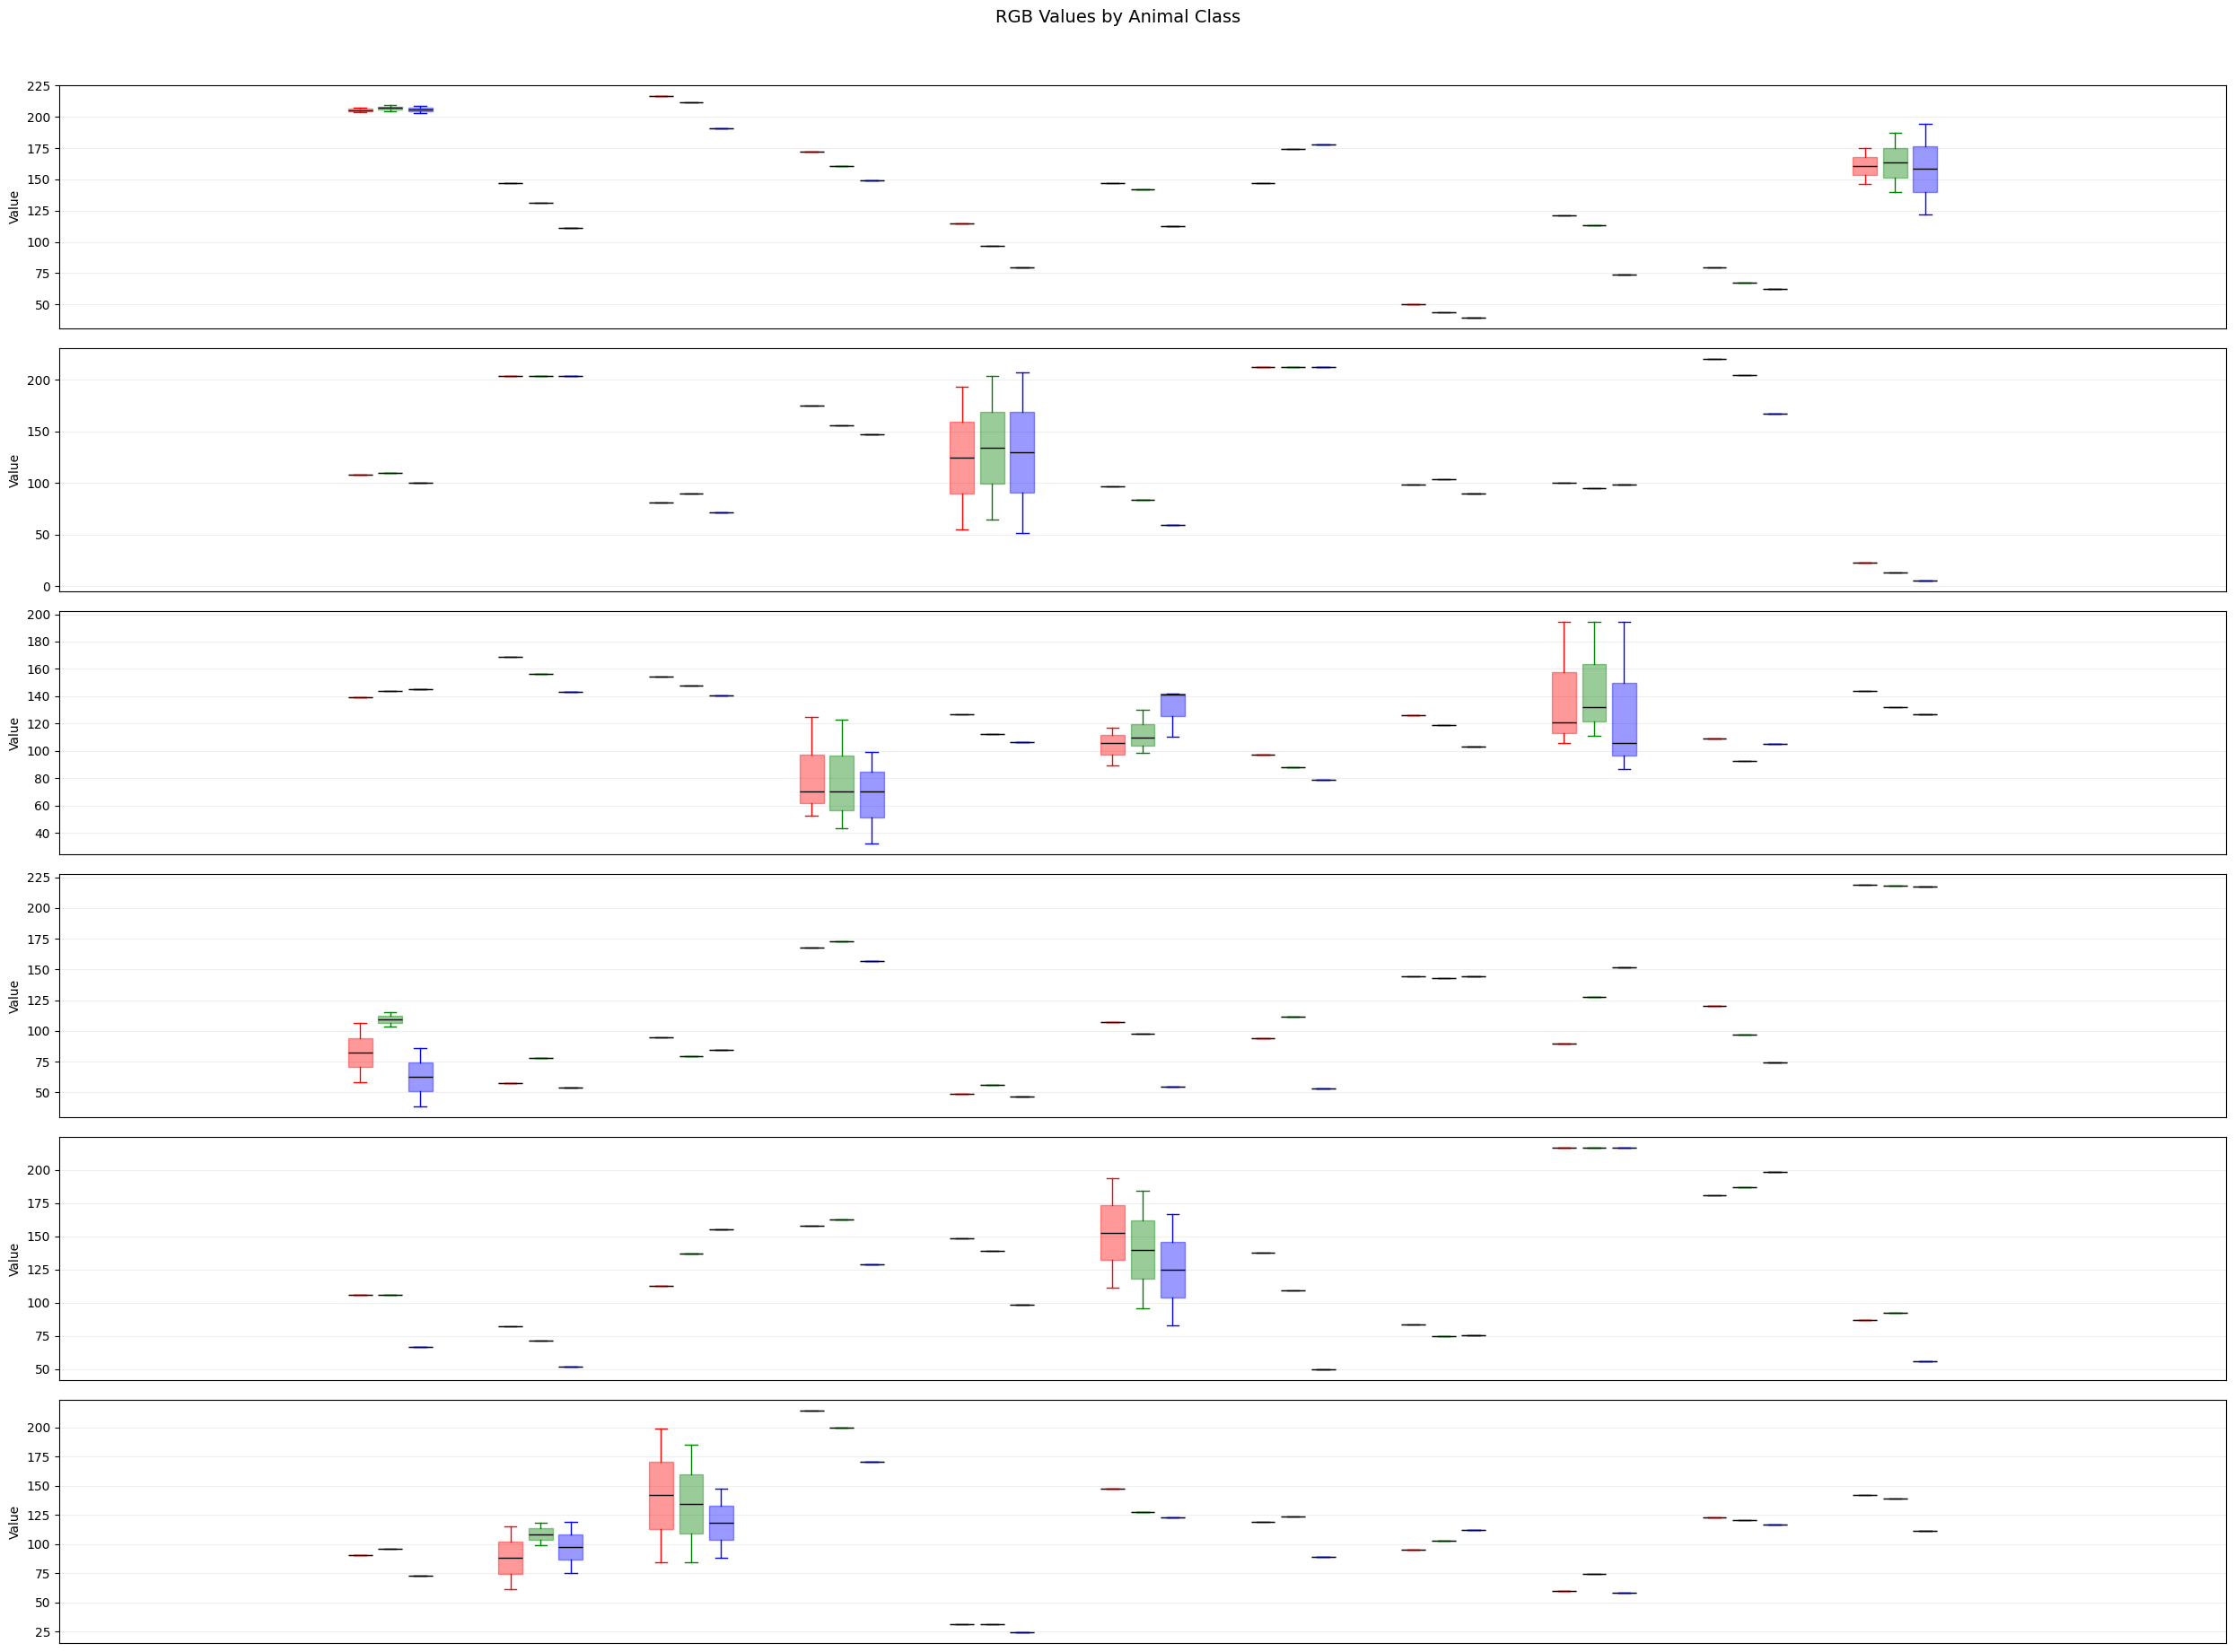

In [ ]:
print("RGB Channel Distribution by Class:")
plot_feature_distribution(train_features, ["red", "green", "blue"], LIGHT_COLORS, "RGB Values by Animal Class")

- Shows the spread of red, green, and blue intensities for each class.

- Helps identify if certain species tend to appear more green (e.g., camouflaged insects) or red (e.g., birds with plumage).

<a class="anchor" id="three-three-bullet"></a>

### 3.3 HSV Features

<a href="#top">Top &#129033;</a>


HSV Color Space Analysis:


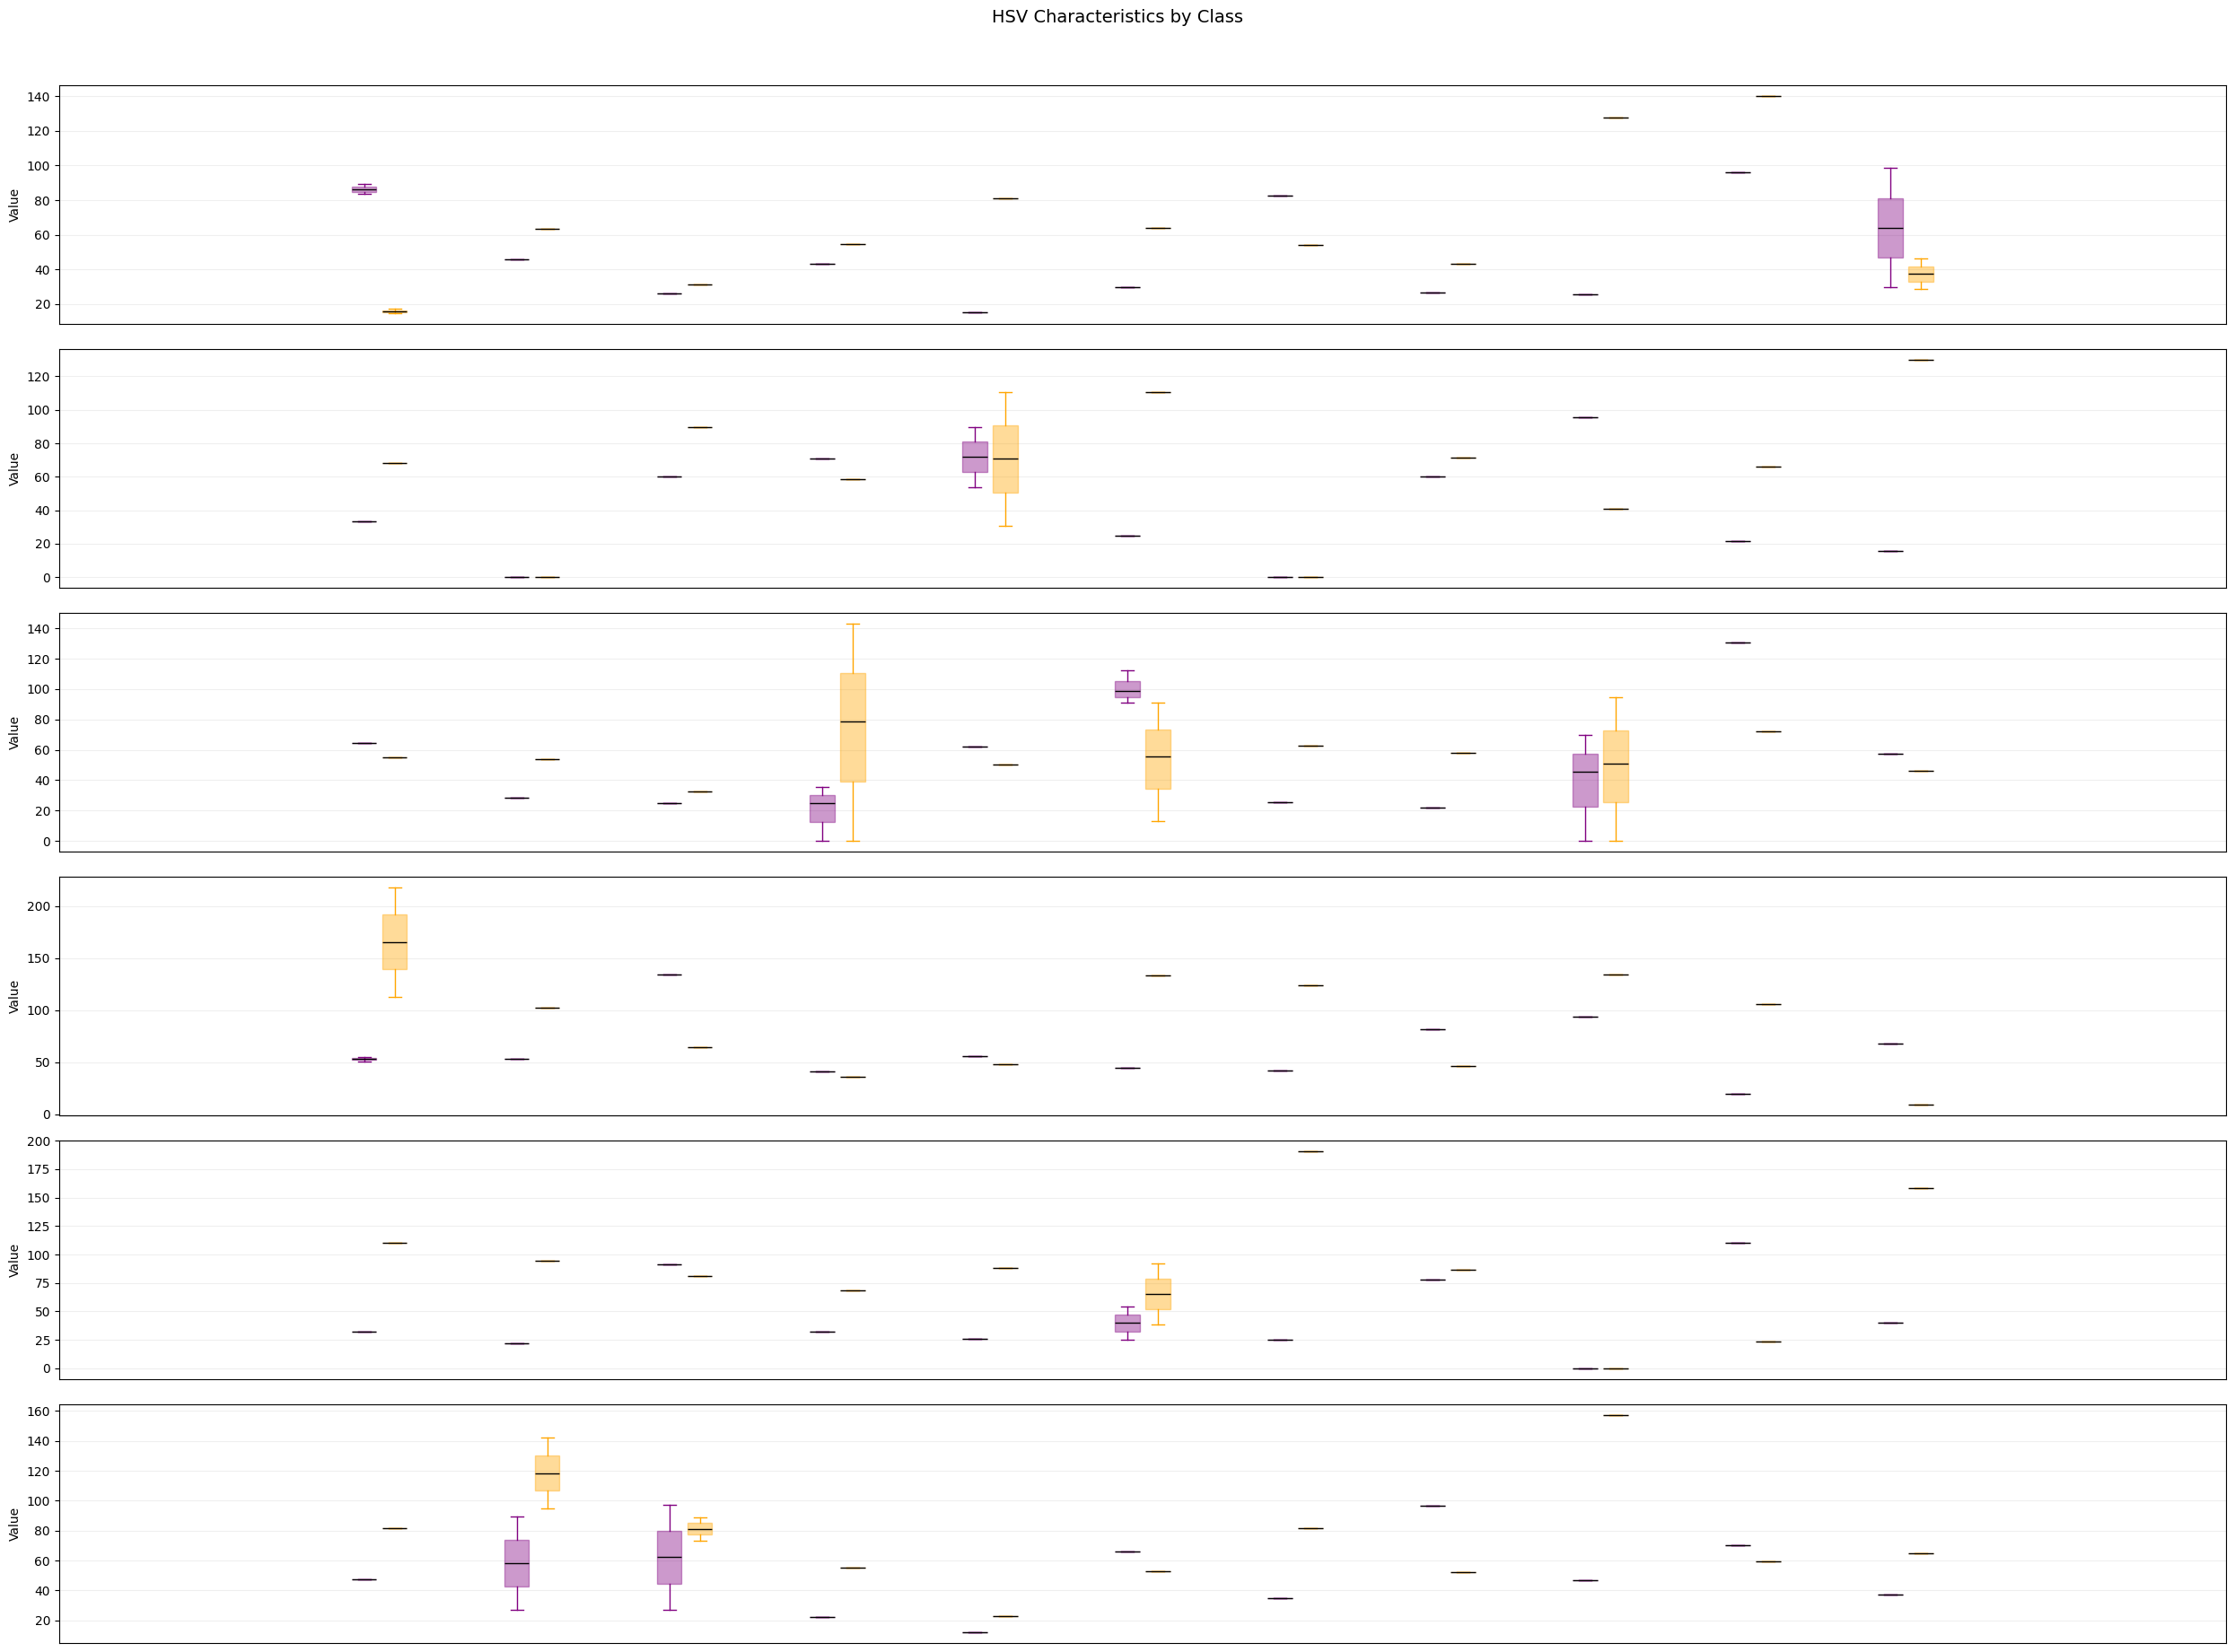

In [ ]:

print("HSV Color Space Analysis:")
plot_feature_distribution(train_features, ["hue", "saturation"], HSV_COLORS, "HSV Characteristics by Class")

- Hue: Represents the dominant color tone (e.g., blue, red, green).

- Saturation: Reflects the intensity of the color, helping differentiate vivid from dull species.

<a class="anchor" id="three-four-bullet"></a>

### 3.4 Image Quality Metrics: Sharpness

<a href="#top">Top &#129033;</a>


Image Quality Metrics:


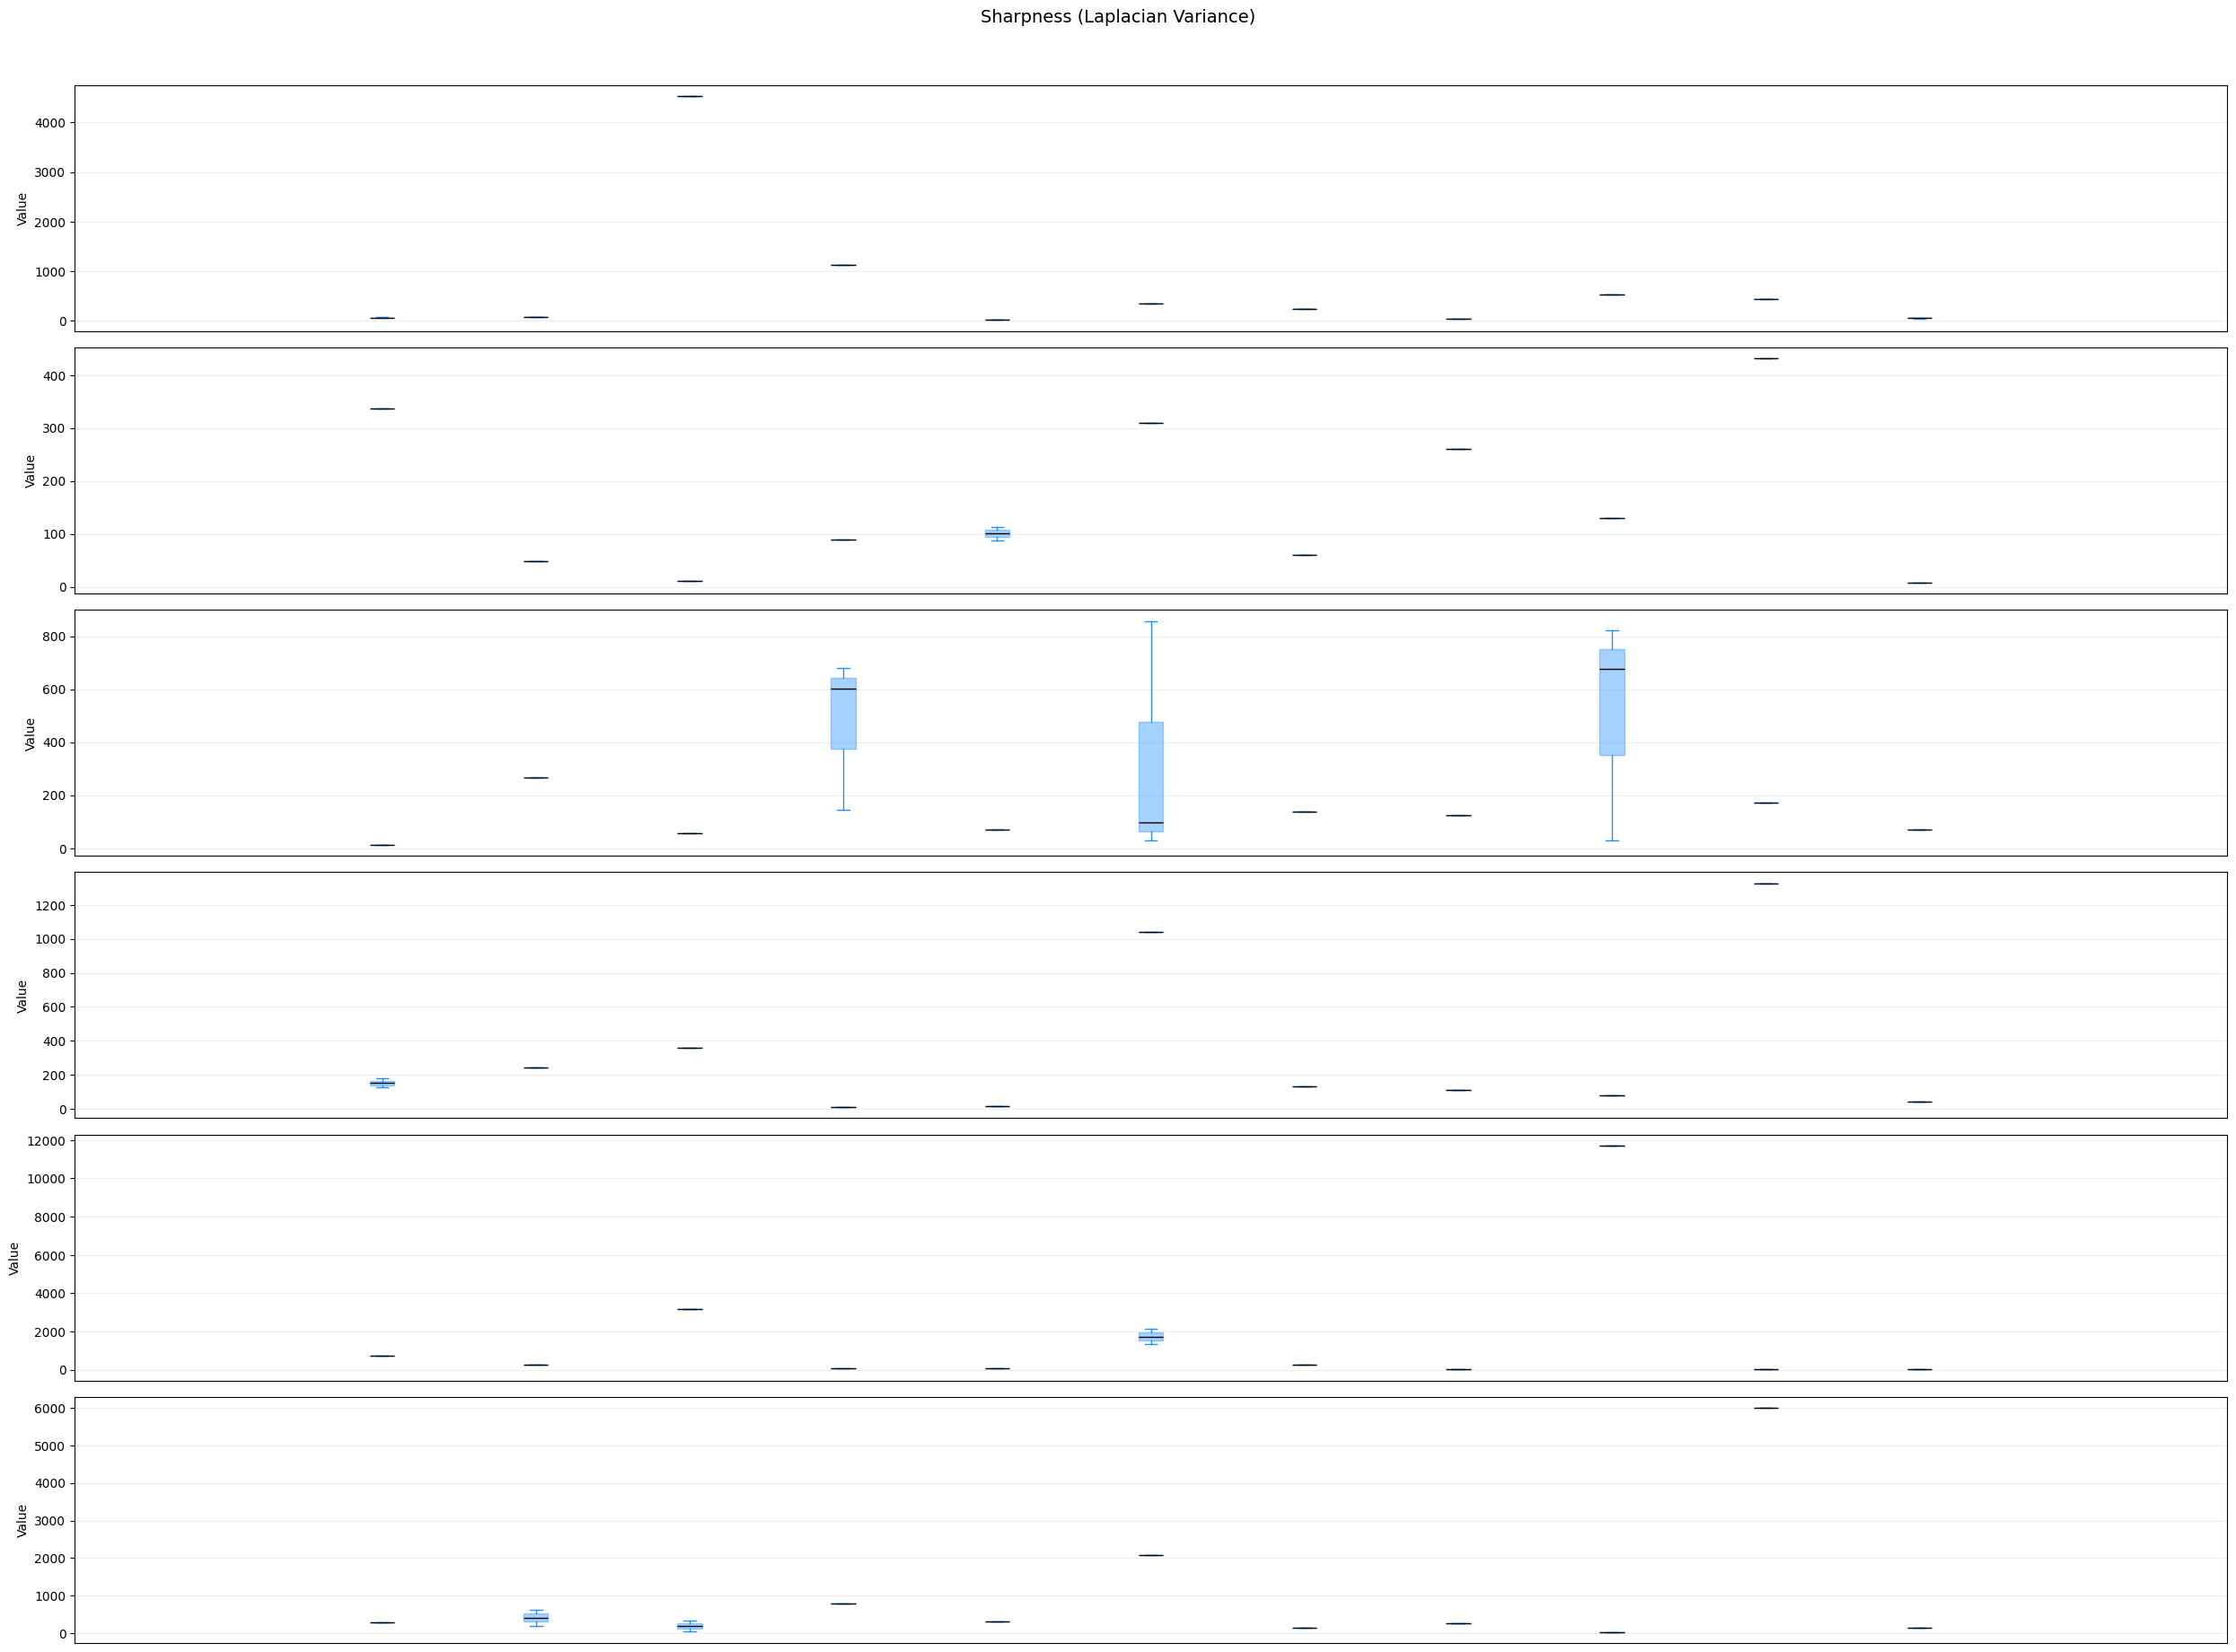

In [ ]:
print("Image Quality Metrics:")
plot_feature_distribution(train_features, ["sharpness"], ["dodgerblue"], "Sharpness (Laplacian Variance)")

This boxplot visualizes the sharpness of each image per class, calculated using the Laplacian variance. A higher value indicates a sharper image (more defined edges), while lower values suggest blur or low contrast.

Sharpness can significantly impact classification accuracy. For example, blurry or out-of-focus images might make it harder for a model (and even humans) to distinguish key visual features.

<a class="anchor" id="three-five-bullet"></a>

### 3.5 Visualizing Extremes in Sharpness

<a href="#top">Top &#129033;</a>


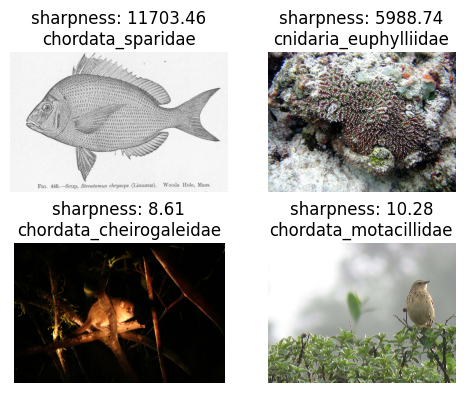

In [ ]:
show_extremes(train_features, "sharpness")

Helps in identifying poor-quality images that might need filtering or special handling.

<a class="anchor" id="three-six-bullet"></a>

### 3.6 Shape Analysis: Morphological Features

<a href="#top">Top &#129033;</a>

Shape Analysis:


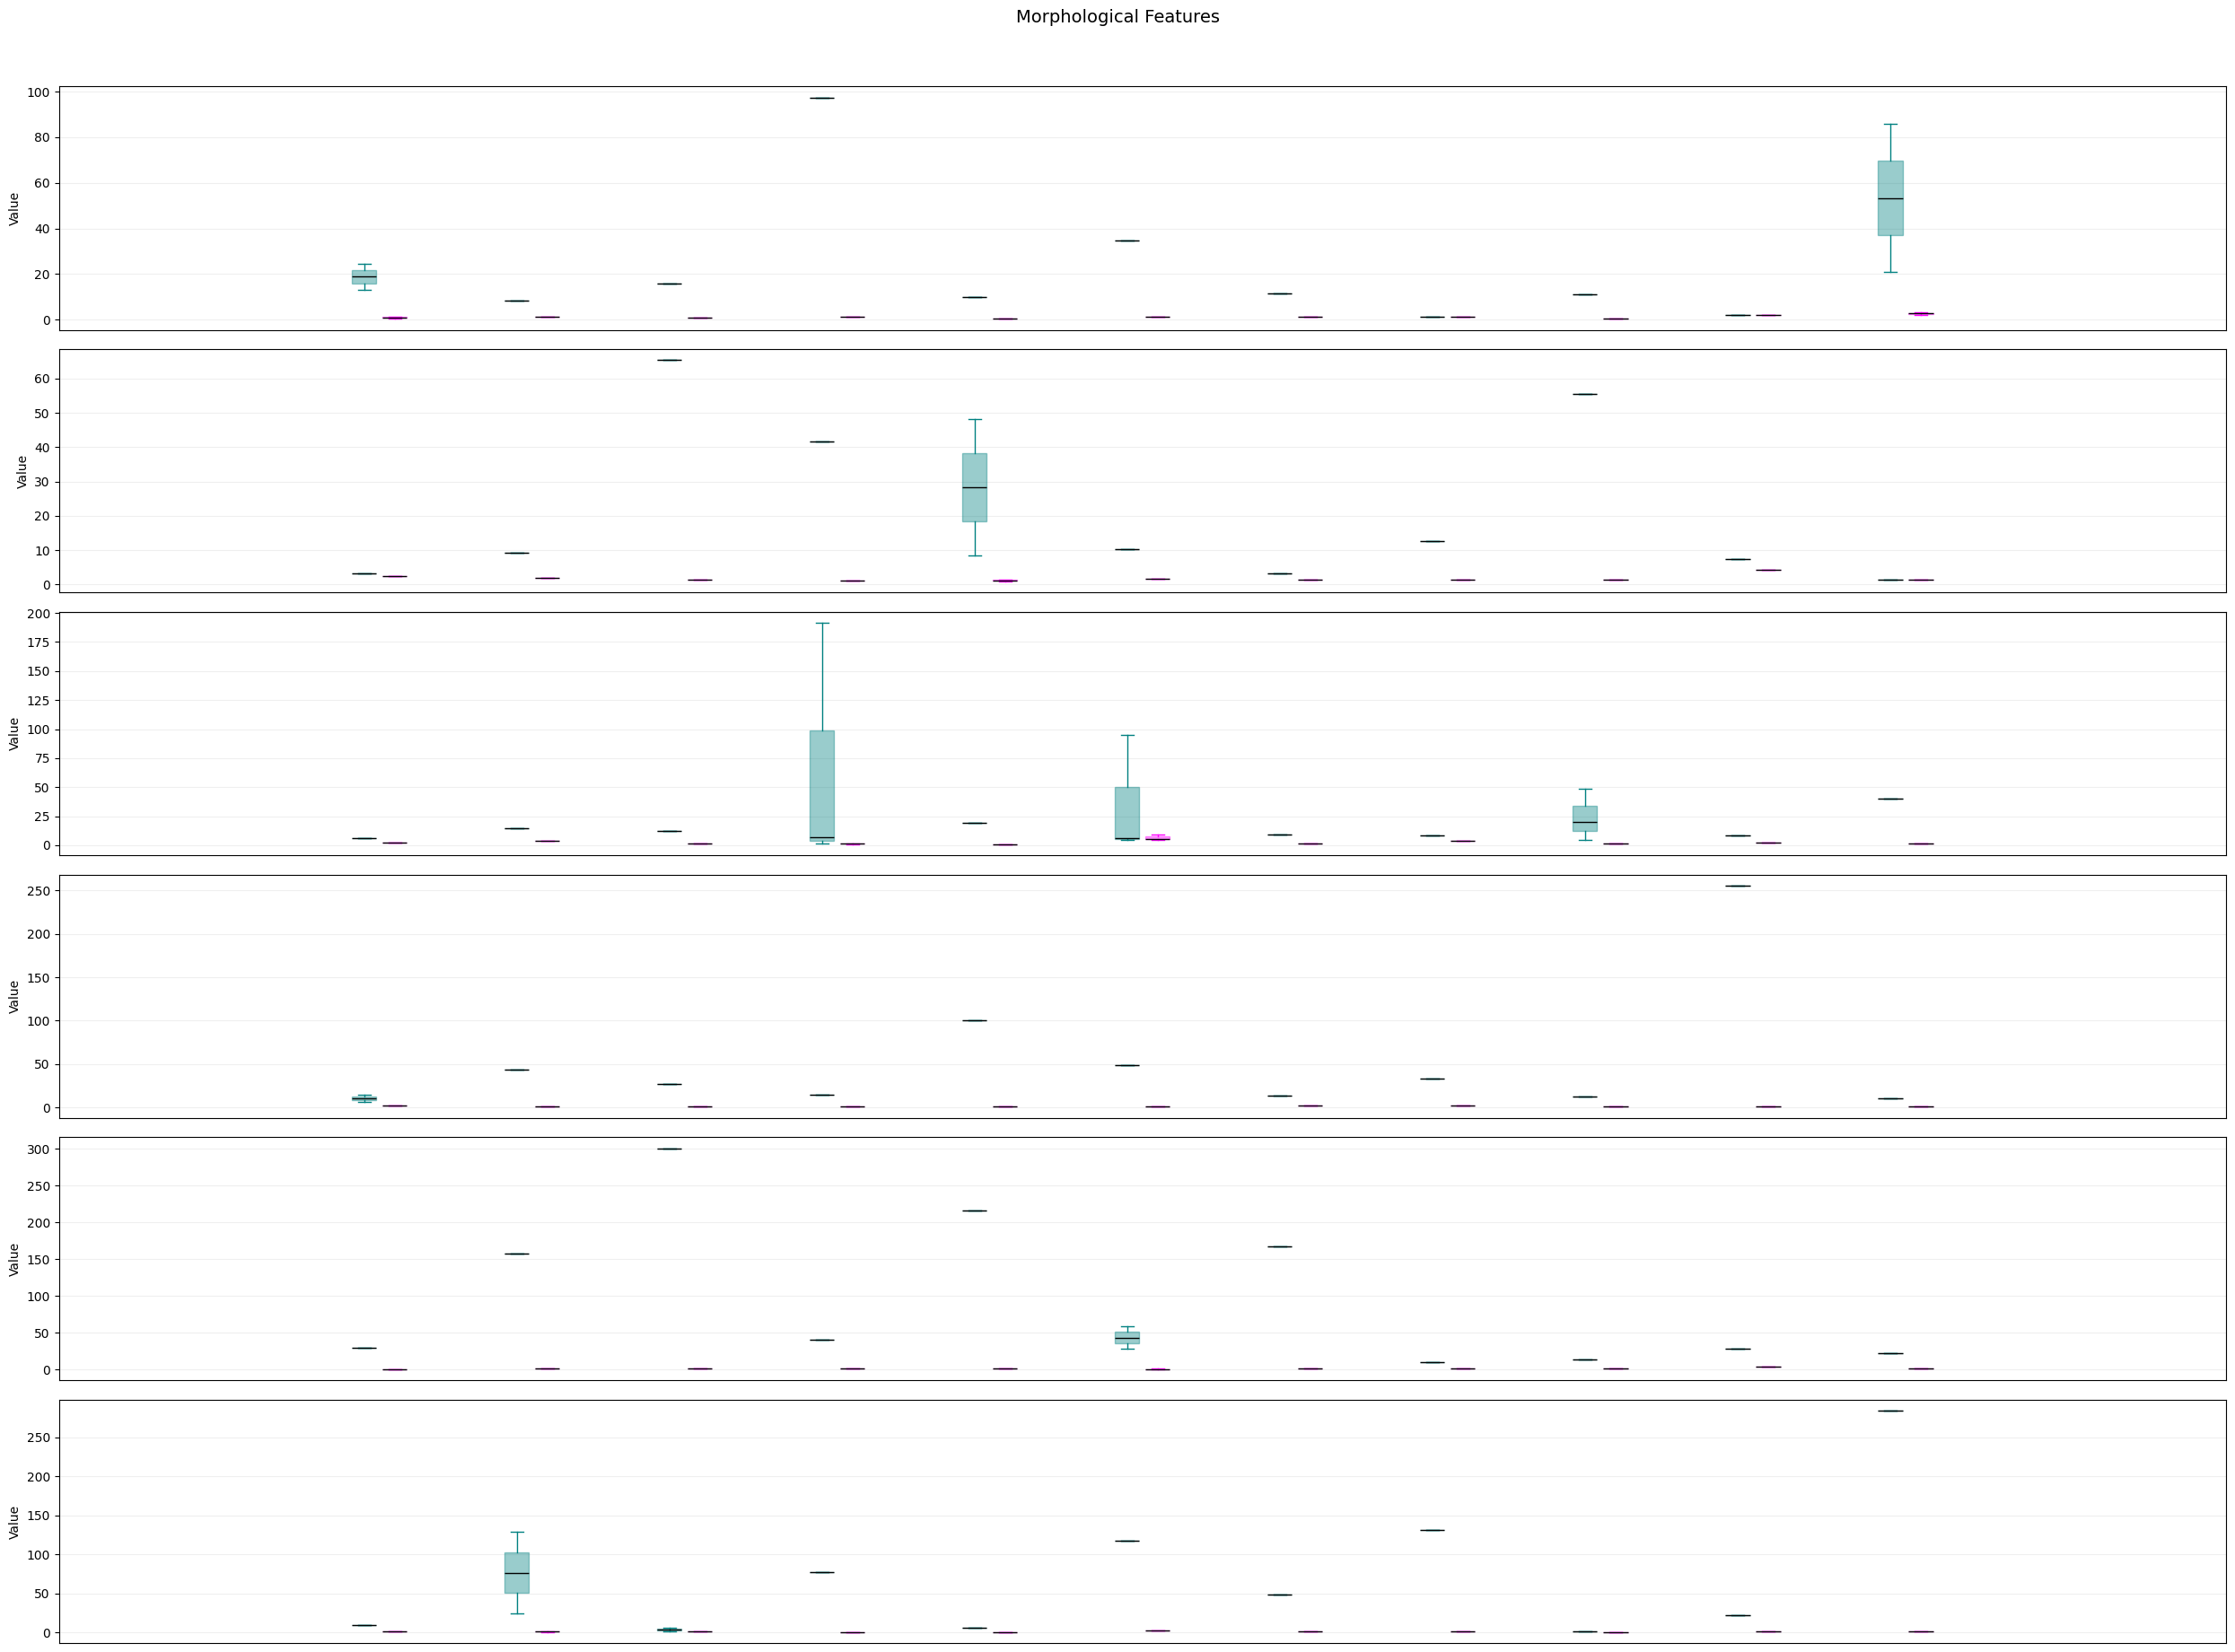

In [ ]:
print("Shape Analysis:")
plot_feature_distribution(train_features, ["compactness", "aspect_ratio"], SHAPE_COLORS[:2], "Morphological Features")


<a class="anchor" id="three-seven-bullet"></a>

### 3.7 Shape Extremes

<a href="#top">Top &#129033;</a>


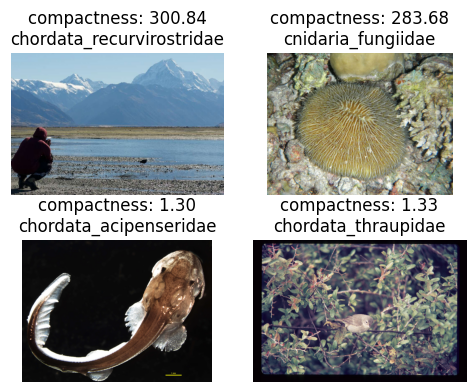

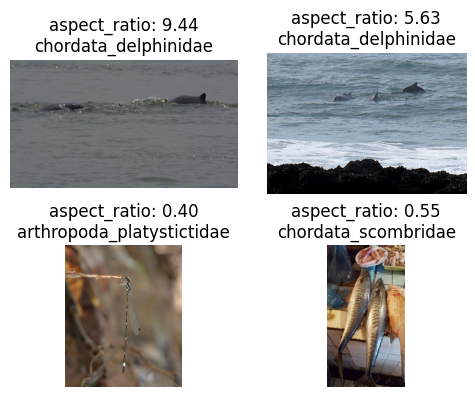

In [ ]:
# Show shape extremes
show_extremes(train_features, "compactness")
show_extremes(train_features, "aspect_ratio")

Top 2 and bottom 2 images for compactness — e.g., very round vs. long or fragmented shapes.

Top 2 and bottom 2 images for aspect ratio — e.g., wide vs. tall object bounding boxes.

<a class="anchor" id="three-eight-bullet"></a>

### 3.8 Foreground Composition: Animal-to-Background Ratio

<a href="#top">Top &#129033;</a>


Foreground Composition:


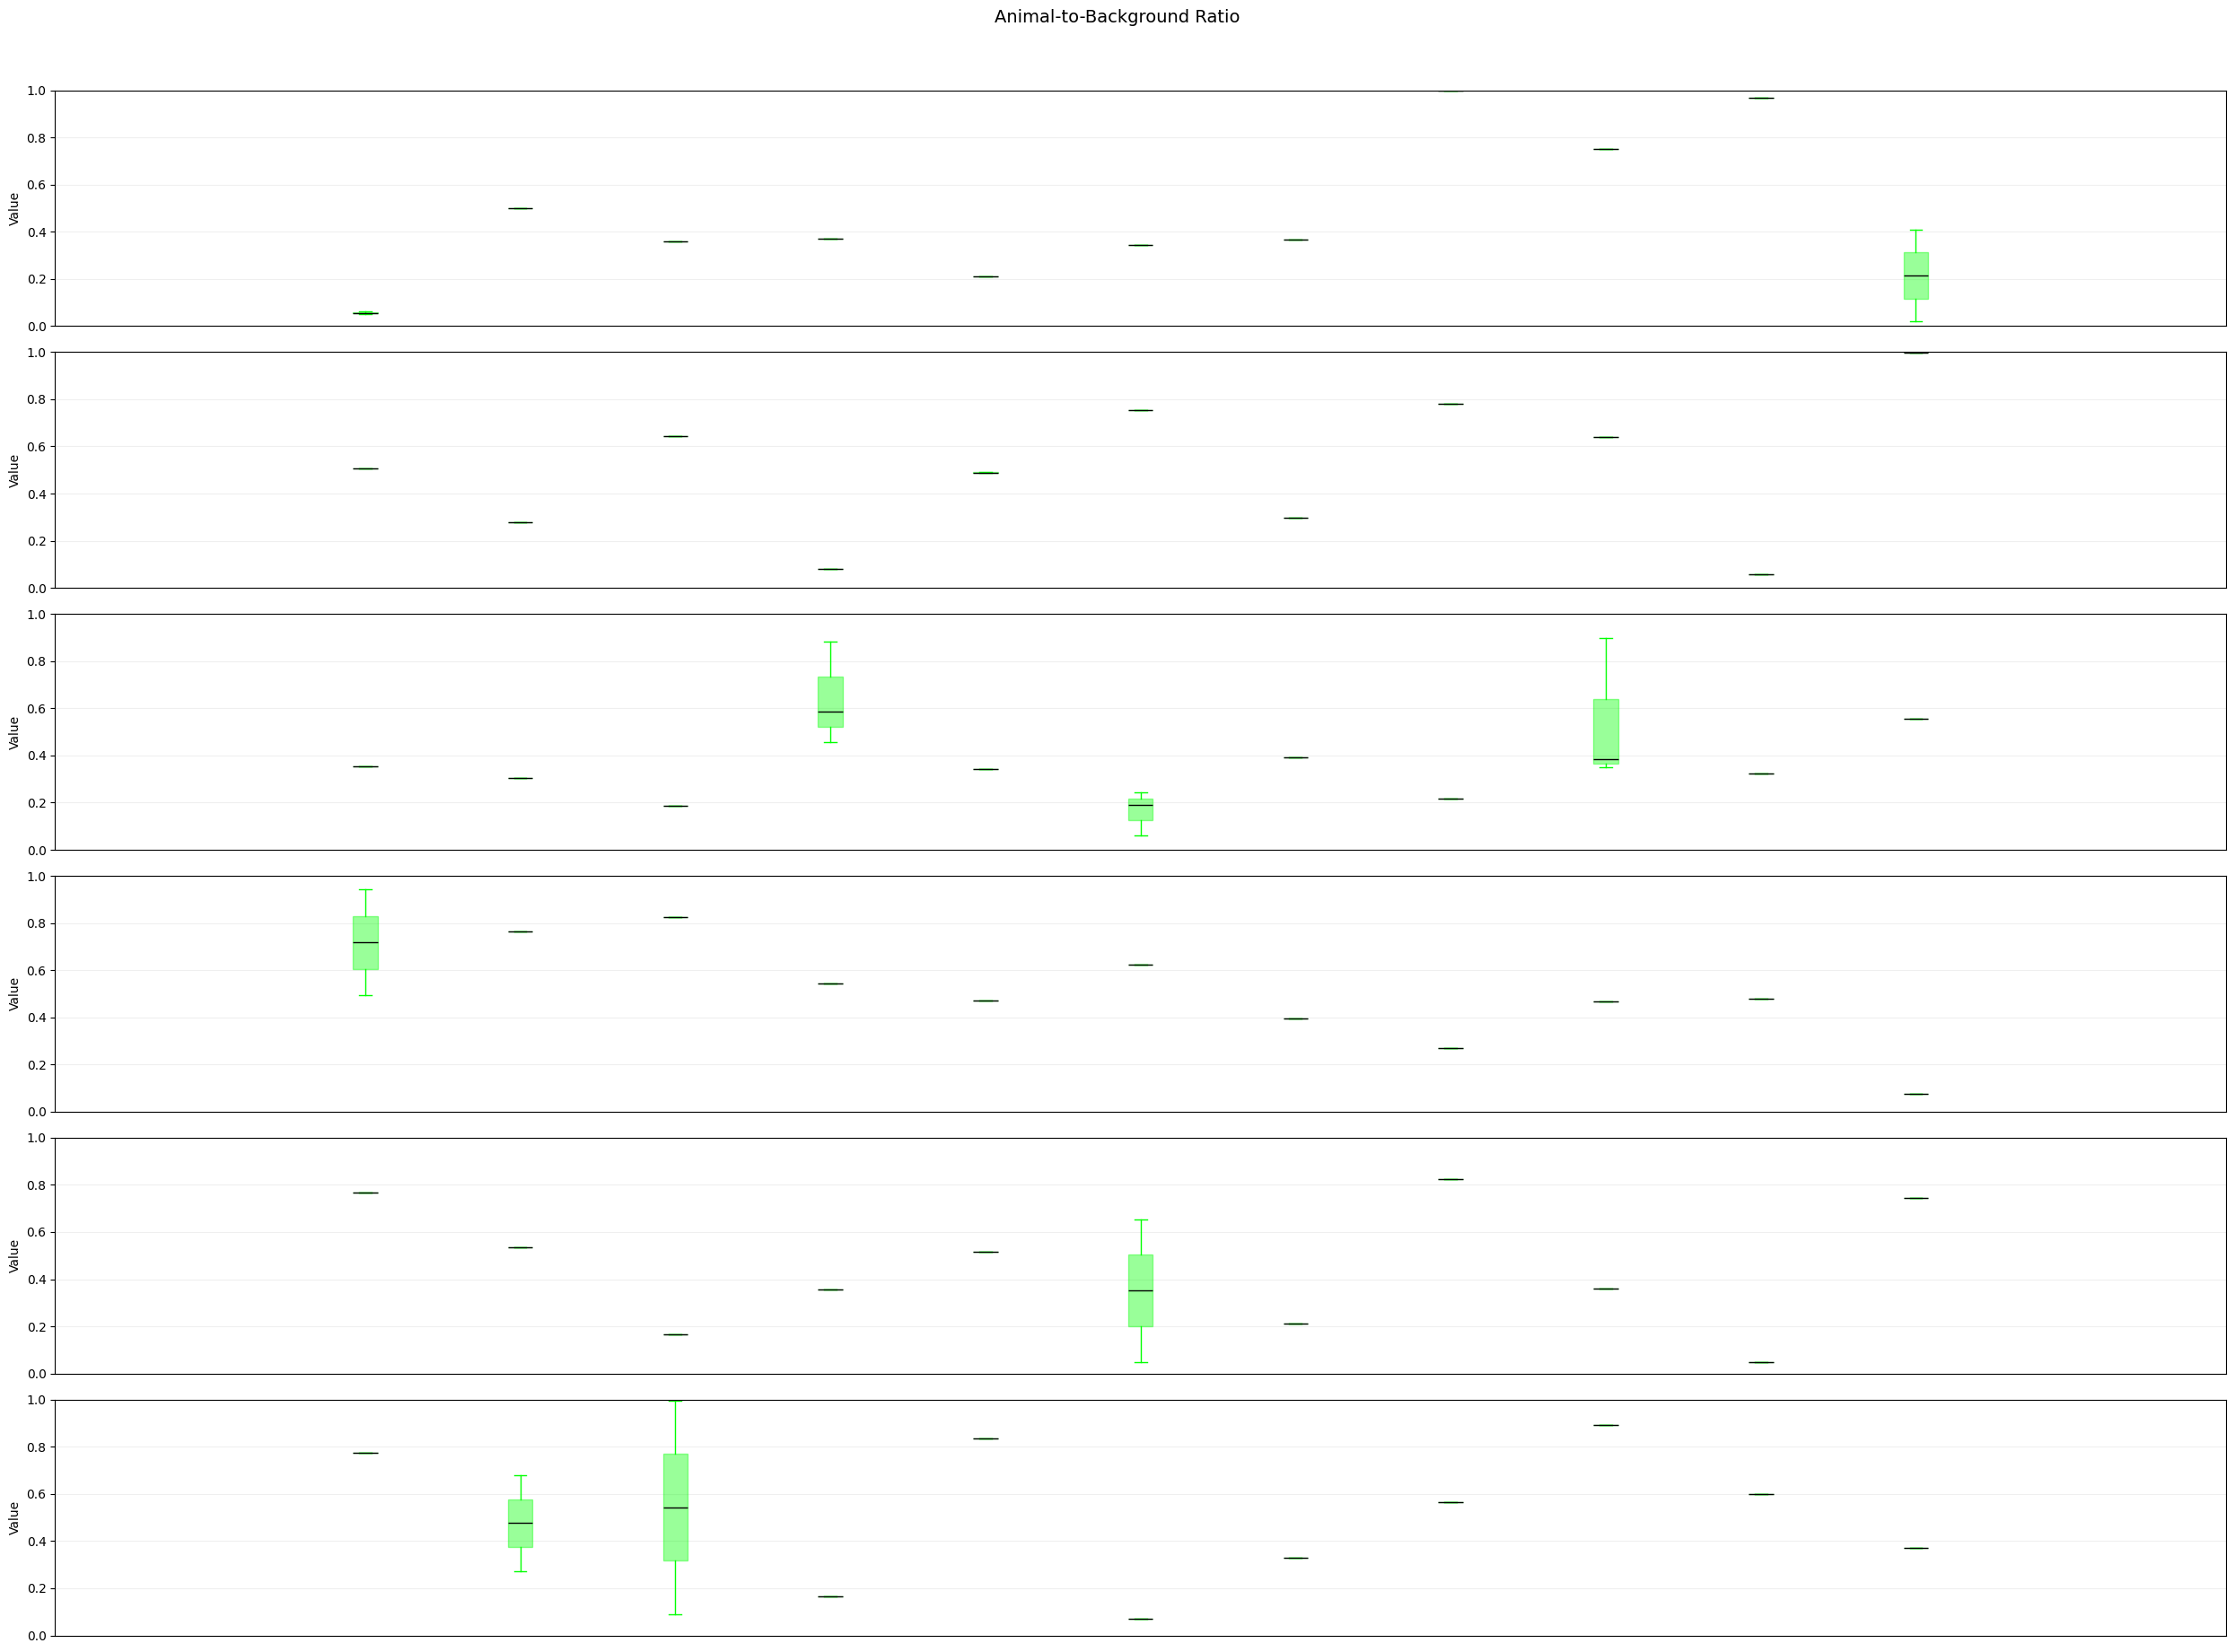

In [ ]:

print("Foreground Composition:")
plot_feature_distribution(train_features, ["foreground_ratio"], FOREGROUND_COLORS[:1], "Animal-to-Background Ratio", ylim=(0,1))


<a class="anchor" id="three-nine-bullet"></a>

### 3.9 Foreground Ratio Extremes

<a href="#top">Top &#129033;</a>


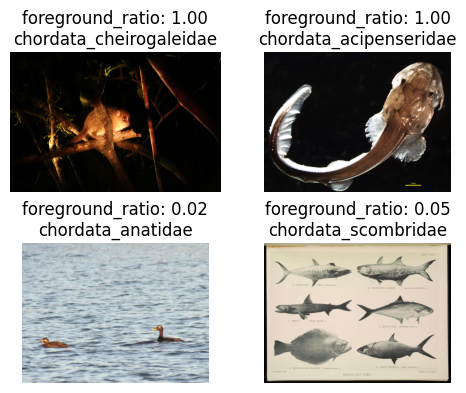

In [ ]:
show_extremes(train_features, "foreground_ratio")

The lowest foreground ratio — where the animal is likely very small or distant.

The highest foreground ratio — where the animal fills most of the frame.

<a class="anchor" id="four-bullet"></a>

## <span style="color:#FF007F">4. CLIP-Based Image Filtering</span>

<a href="#top">Top &#129033;</a>

This section uses OpenAI’s CLIP model to detect and filter out images that don’t match animal-like prompts (e.g., drawings, maps, skeletons, etc.). It’s designed to clean the dataset before training, especially useful in datasets with noisy labels or mixed content.

In [ ]:
import torch
import clip
from PIL import Image
import os
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import math

# =============================================================================
# CONFIGURATION AND FUNCTIONS
# =============================================================================

# Main configurations
DATA_ROOT = "../data/"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GRID_SIZE = 40  # Number of images per grid

# List of prompts
ANIMAL_PROMPTS = [
    "a clear photo of a single animal with distinct features",
    "a detailed close-up of a animal"s body",
    "a wild animal in natural environment with proper proportions",
    "a healthy animal in natural lighting",
    "close-up of animal face with clear features",
    "two or more animals same specie",
    "little animal",
    "insect",
    "amphibian",
    "mammal",
    "fish",
    "bird"
]

NON_ANIMAL_PROMPTS = [
    "scientific illustration",
    "pencil drawing of animal species",
    "geographical map or chart",
    "animal on human hands",
    "text document or book page",
    "trees without animals",
    "animal skeleton or bone structure",
    "landscape no animals"
]

def create_prediction_df(df_name, device=DEVICE):
    """
    Creates a DataFrame of predictions for a specific part of the dataset.
    
    Args:
        df_name: Name of the dataset (train/val/test)
        device: Processing device
    
    Returns:
        DataFrame with CLIP predictions
    """
    # Load image paths
    df = pd.read_csv(f"{DATA_ROOT}{df_name}_df.csv")
    image_paths = [f"{DATA_ROOT}{p}" for p in df["file_path"]]
    
    # Load CLIP model
    model, preprocess = clip.load("ViT-B/32", device=device)
    all_prompts = ANIMAL_PROMPTS + NON_ANIMAL_PROMPTS
    
    # Preprocess text
    text_inputs = torch.cat([clip.tokenize(prompt) for prompt in all_prompts]).to(device)
    
    with torch.no_grad():
        text_features = model.encode_text(text_inputs)
        text_features /= text_features.norm(dim=-1, keepdim=True)
    
    results = []
    
    for path in tqdm(image_paths, desc=f"Processing {df_name}"):
        true_class = os.path.basename(os.path.dirname(path))
        
        # Process image
        image = preprocess(Image.open(path)).unsqueeze(0).to(device)
        with torch.no_grad():
            image_features = model.encode_image(image)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            
            # Calculate similarity scores
            logits = (100.0 * image_features @ text_features.T).softmax(dim=-1)
            
            # Get top 3 matches
            probs, indices = logits.topk(3)
            top_matches = [
                (all_prompts[i], p.item())  # No string replacement
                for p, i in zip(probs[0], indices[0])
            ]
            
        results.append({
            "path": path,
            "true_class": true_class,
            "top1_match": top_matches[0][0] if len(top_matches) > 0 else None,
            "top1_prob": top_matches[0][1] if len(top_matches) > 0 else 0,
            "top2_match": top_matches[1][0] if len(top_matches) > 1 else None,
            "top2_prob": top_matches[1][1] if len(top_matches) > 1 else 0,
            "top3_match": top_matches[2][0] if len(top_matches) > 2 else None,
            "top3_prob": top_matches[2][1] if len(top_matches) > 2 else 0
        })
    
    return pd.DataFrame(results)

def create_grid(image_data, grid_num, df_name):
    """Creates a grid of images with non-animal matches"""
    output_dir = f"../data_preproc/clip_grids/{df_name}"
    os.makedirs(output_dir, exist_ok=True)
    GRID_COLS = 4
    num_images = len(image_data)
    rows = math.ceil(num_images / GRID_COLS)
    
    fig, axs = plt.subplots(rows, GRID_COLS, figsize=(20, rows*4))
    
    # Handle case where we don"t have enough images to fill the grid
    if num_images < rows * GRID_COLS:
        for i in range(num_images, rows * GRID_COLS):
            fig.delaxes(axs.flatten()[i])
    
    # Add images to grid
    for ax, data in zip(axs.flat[:num_images], image_data):
        img = Image.open(data["path"])
        ax.imshow(img)
        ax.set_title(
            f"Class: {data["true_class"]}\n"
            f"Match: {data["top1_match"]}\n"
            f"Prob: {data["top1_prob"]:.2f}",
            fontsize=15
        )

        ax.axis("off")
    
    plt.tight_layout()   
    plt.savefig(f"{output_dir}/grid_{grid_num:03d}.png")
    plt.close()

# =============================================================================
# MAIN EXECUTION (CHOOSE AN OPTION)
# =============================================================================
def process_clip_predictions(dataset_type, non_animal_prompts, grid_size=40):
    # Generate predictions
    predictions = create_prediction_df(dataset_type)
    
    # Save CSV
    csv_path = f"../data_preproc/{dataset_type}_clip_predictions.csv"
    predictions.to_csv(csv_path, index=False)
    
    # Filter non-animals
    non_animal_df = predictions[predictions["top1_match"].isin(non_animal_prompts)]
    
    # Generate grids
    print(f"\nGenerating grids for {dataset_type} ({len(non_animal_df)} non-animal samples):")
    for i in range(0, len(non_animal_df), grid_size):
        batch = non_animal_df[i:i+grid_size].to_dict("records")
        create_grid(batch, grid_num=i//grid_size, df_name=dataset_type)
    
    print(f"Processing of {dataset_type} completed.\n{"="*50}")

# Process all datasets
for dataset in [ "val", "test"]:#"train",
    process_clip_predictions(
        dataset_type=dataset,
        non_animal_prompts=NON_ANIMAL_PROMPTS,
        grid_size=40
    )


Processing val: 100%|██████████| 1797/1797 [09:32<00:00,  3.14it/s]



Generating grids for val (212 non-animal samples):
Processing of val completed.


Processing test: 100%|██████████| 1798/1798 [10:17<00:00,  2.91it/s]



Generating grids for test (207 non-animal samples):
Processing of test completed.


<a class="anchor" id="four-one-bullet"></a>

### 4.1 Reclassify Non-Animal Samples Using CLIP Predictions

<a href="#top">Top &#129033;</a>

This part of the code allows you to reclassify certain images as "non-animal" based on CLIP model predictions. This can be helpful for datasets where a portion of the data does not fit the animal categories.



In [ ]:
def reclassify_clip_predictions(dataset_type, non_animal_prompts, prob_threshold=0.64):
    """
    Reclassify non-animal samples to a special "non_animal" class.
    
    Args:
        dataset_type: "train", "val", or "test"
        non_animal_prompts: List of non-animal prompts
        prob_threshold: Probability threshold for reclassification
    """
    # Load predictions
    input_path = f"../data_preproc/{dataset_type}_clip_predictions.csv"
    df = pd.read_csv(input_path)
    
    # Create a copy for modification
    modified_df = df.copy()
    
    # Identify and reclassify non-animal samples
    non_animal_mask = (modified_df["top1_prob"] > prob_threshold) & \
                      (modified_df["top1_match"].isin(non_animal_prompts))
    
    modified_df.loc[non_animal_mask, "true_class"] = "non_animal"
    
    # Save the results
    output_path = f"../data_preproc/{dataset_type}_df_clip.csv"
    modified_df.to_csv(output_path, index=False)
    
    # Generate a report
    print(f"\nReclassification completed for {dataset_type}:")
    print(f"Original records: {len(df)}")
    print(f"Records reclassified as "non_animal": {non_animal_mask.sum()}")
    print(f"New total number of classes: {modified_df["true_class"].nunique()}")
    print("-"*50)

for dataset in [ "train","val", "test"]:
    reclassify_clip_predictions(
        dataset_type=dataset,
        non_animal_prompts=NON_ANIMAL_PROMPTS,
        prob_threshold=0.6
    )



Reclassification completed for val:
Original records: 1797
Records reclassified as 'non_animal': 125
New total number of classes: 203
--------------------------------------------------

Reclassification completed for test:
Original records: 1798
Records reclassified as 'non_animal': 130
New total number of classes: 203
--------------------------------------------------


<a class="anchor" id="four-two-bullet"></a>

### 4.2 Class Distribution

<a href="#top">Top &#129033;</a>


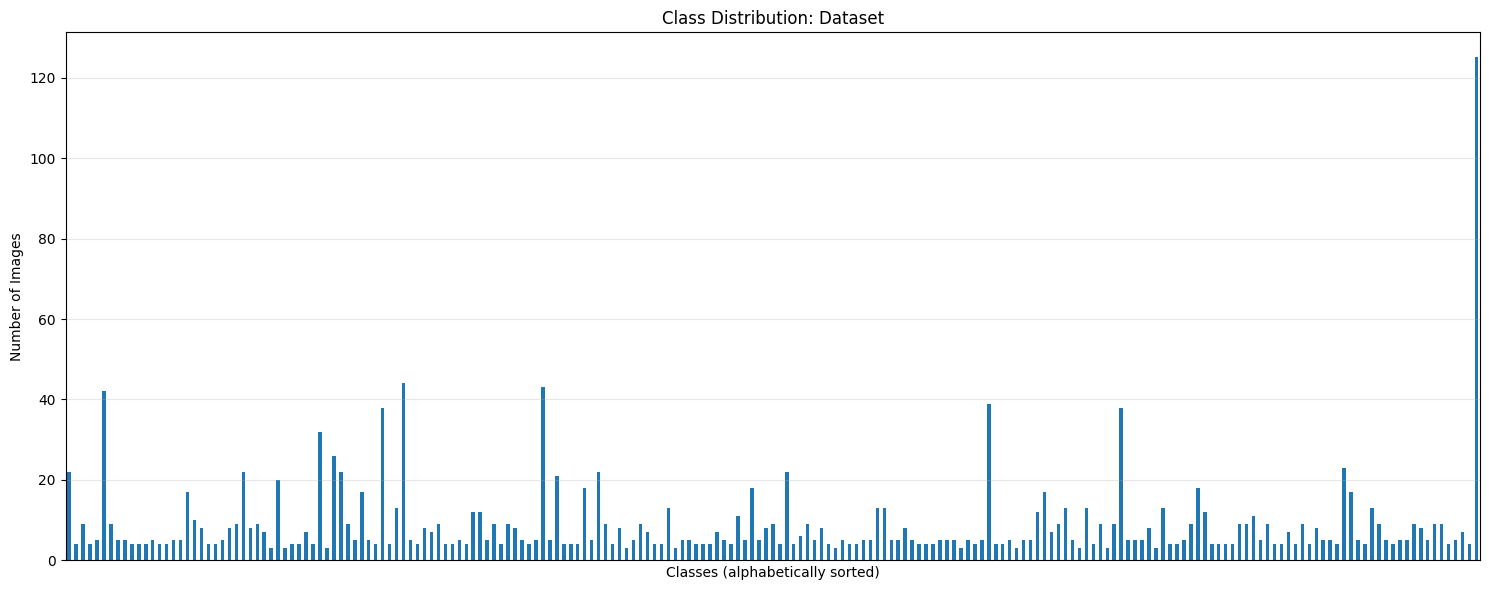

In [ ]:
import os


def plot_class_distribution(df, dataset_name="Dataset"):
    
    # Count classes and sort alphabetically
    class_counts = df["true_class"].value_counts().sort_index()
    
    # Plot
    plt.figure(figsize=(15, 6))
    class_counts.plot(kind="bar")
    plt.title(f"Class Distribution: {dataset_name}")
    plt.xlabel("Classes (alphabetically sorted)")
    plt.ylabel("Number of Images")
    plt.xticks([])
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

train_df_clip = pd.read_csv("../data_preproc/val_df_clip.csv")
plot_class_distribution(train_df_clip)

<a class="anchor" id="five-bullet"></a>

## <span style="color:#FF007F">5. Augmentation as a Data Balancer</span>

<a href="#top">Top &#129033;</a>


In [ ]:
# import os
# import cv2
# import albumentations as A
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from albumentations.pytorch import ToTensorV2
# from itertools import cycle
# import random

# class AnimalDataAugmenter:
#     def __init__(self, sample_df, dataset_type="train"):
#         """
#         Args:
#             sample_df: DataFrame contendo caminhos e true_class
#             dataset_type: "train", "val", ou "test" - determina prefixos
#         """
#         self.sample_df = sample_df
#         self.dataset_type = dataset_type.lower()
#         assert self.dataset_type in ("train", "val", "test"), "Tipo de dataset inválido"
        
#         self.base_path = "../data"
#         self.augmentation_dir = f"../data_preproc/{self.dataset_type}_data_clip_augmentation"
#         self.grids_dir = f"../data_preproc/augmentation_grids/{self.dataset_type}"
        
#         # Criar diretórios
#         os.makedirs(self.augmentation_dir, exist_ok=True)
#         os.makedirs(self.grids_dir, exist_ok=True)
        
#         # Pipeline de augmentação modificada
#         self.augmenter = A.Compose([
#             A.Resize(height=512, width=512),
#             A.HorizontalFlip(p=0.5),
#             A.VerticalFlip(p=0.2),
#             A.Rotate(limit=45, 
#                     border_mode=cv2.BORDER_REFLECT_101,  # Aqui está a modificação
#                     p=0.7),
#             A.RandomScale(scale_limit=0.3, p=0.8),
#             A.Affine(scale=(0.8, 1.2)), 
#             A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
#             A.CLAHE(p=0.4),
#             A.GaussianBlur(blur_limit=(3, 7), p=0.3),
#             A.RandomGamma(gamma_limit=(80, 120), p=0.3),
#             A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.5),
#             A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#             ToTensorV2()
#         ], p=1)

#     def _calculate_quartile_targets(self, class_counts):
#         counts = np.array(list(class_counts.values()))
#         classes = list(class_counts.keys())
#         sorted_indices = np.argsort(counts)
#         sorted_counts = counts[sorted_indices]
        
#         median = np.median(counts)
#         min_count = min(counts)
        
#         # Calculate scaling factors
#         scale_factors = np.zeros_like(counts, dtype=float)
#         for i, count in enumerate(sorted_counts):
#             if count < median:
#                 # Aggressive scaling for small classes (1000% down to 65%)
#                 scale = 10.0 - (10.0 - 0.65) * (count - min_count) / (median - min_count)
#             else:
#                 # Small scaling for large classes (10%)
#                 scale = 0.1
#             scale_factors[sorted_indices[i]] = scale
        
#         # Apply scaling while maintaining order
#         targets = np.zeros_like(counts)
#         last_target = 0
#         for i in sorted_indices:
#             raw_target = counts[i] * (1 + scale_factors[i])
#             targets[i] = max(raw_target, last_target + 1) if i > 0 else raw_target
#             last_target = targets[i]
        
#         return dict(zip(classes, np.round(targets).astype(int)))

#     def generate_augmentations(self):
#         class_groups = self.sample_df.groupby("true_class")
#         class_counts = self.sample_df["true_class"].value_counts().to_dict()
#         targets = self._calculate_quartile_targets(class_counts)

#         for class_name, group in class_groups:
#             original_count = len(group)
#             target = targets[class_name]
            
#             if target <= original_count:
#                 continue
                
#             needed = target - original_count
#             class_aug_dir = os.path.join(self.augmentation_dir, class_name)
#             os.makedirs(class_aug_dir, exist_ok=True)
            
#             # Salvar originais
#             for _, row in group.iterrows():
#                 try:
#                     img_path = row["path"]
#                     img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
#                     if img is None:
#                         raise FileNotFoundError(img_path)
                    
#                     original_filename = os.path.basename(img_path)
#                     prefixed_name = f"{self.dataset_type}_{original_filename}"
#                     cv2.imwrite(os.path.join(class_aug_dir, prefixed_name),
#                               cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
#                 except Exception as e:
#                     print(f"Error processing {img_path}: {str(e)}")
#                     continue

#             # Nova lógica de augmentação aleatória
#             batch = []
#             grid_num = 0
#             aug_count = 0
#             image_list = group.to_dict("records")
            
#             while aug_count < needed:
#                 try:
#                     # Seleção aleatória com substituição
#                     row = random.choice(image_list)
#                     img_path = row["path"]
#                     img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
#                     if img is None:
#                         continue
                    
#                     # Aumento aleatório único
#                     augmented = self.augmenter(image=img)["image"]
#                     aug_count += 1
                    
#                     # Nome único baseado no timestamp
#                     base_name = os.path.splitext(os.path.basename(img_path))[0]
#                     unique_id = f"{aug_count}_{np.random.randint(1000):04d}"
#                     aug_path = os.path.join(
#                         class_aug_dir, 
#                         f"{self.dataset_type}_{base_name}_aug{unique_id}.jpg"
#                     )
                    
#                     # Conversão e salvamento
#                     aug_np = augmented.permute(1, 2, 0).numpy()
#                     aug_np = (aug_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]) * 255
#                     cv2.imwrite(aug_path, cv2.cvtColor(aug_np.clip(0, 255).astype("uint8"), cv2.COLOR_RGB2BGR))
                    
#                     # Geração de grid
#                     batch.append(augmented)
#                     if len(batch) >= 100:
#                         self._save_grid(batch, class_name, grid_num)
#                         grid_num += 1
#                         batch = []
                        
#                 except Exception as e:
#                     print(f"Error during augmentation of {img_path}: {str(e)}")
#                     continue

#             if batch:
#                 self._save_grid(batch, class_name, grid_num)

#     def _save_grid(self, images, class_name, grid_num):
#         plt.figure(figsize=(25, 25))
#         plt.suptitle(f"{self.dataset_type.capitalize()} - Animal Class: {class_name}\nGrid: {grid_num}", 
#                     y=0.92, fontsize=18)
        
#         for i in range(100):
#             plt.subplot(10, 10, i+1)
#             if i < len(images):
#                 img = images[i].permute(1, 2, 0).numpy()
#                 img = (img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]) * 255
#                 plt.imshow(img.clip(0, 255).astype("uint8"))
#             plt.axis("off")
        
#         plt.savefig(os.path.join(self.grids_dir, 
#                                f"{self.dataset_type}_{class_name}_grid_{grid_num}.png"),
#                    dpi=150, bbox_inches="tight")
#         plt.close()
# # =============================================================================
# # EXECUÇÃO PRINCIPAL (ESCOLHA UMA OPÇÃO)
# # =============================================================================

# # Constantes compartilhadas
# BASE_PATH = "../data"
# DATA_PREPROC_PATH = "../data_preproc/"

# # Função de verificação unificada
# def verify_augmentation(dataset_type):
#     aug_dir = f"{DATA_PREPROC_PATH}data_clip_augmentation_{dataset_type}"
#     grid_dir = f"{DATA_PREPROC_PATH}augmentation_{dataset_type}"

#     print(f"\nVerificação para {dataset_type}:")
#     print(f"- Diretório de augmentação: {len(os.listdir(aug_dir))} classes")
#     print(f"- Grids gerados: {len(os.listdir(grid_dir))} arquivos")


# # Opção 1: Para dados de treino
# train_df = pd.read_csv(f"{DATA_PREPROC_PATH}train_df_clip.csv")
# train_augmenter = AnimalDataAugmenter(train_df, "train")
# train_augmenter.generate_augmentations()

Error during augmentation of ../data/chordata_laridae/21923660_45509321_eol-full-size-copy.jpg: <built-in function LUT> returned a result with an exception set
Error during augmentation of ../data/chordata_laridae/21923655_45509321_eol-full-size-copy.jpg: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\alloc.cpp:73: error: (-4:Insufficient memory) Failed to allocate 8386560 bytes in function 'cv::OutOfMemoryError'

Error during augmentation of ../data/chordata_laridae/30123063_45516169_eol-full-size-copy.jpg: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\alloc.cpp:73: error: (-4:Insufficient memory) Failed to allocate 1948908 bytes in function 'cv::OutOfMemoryError'

Error during augmentation of ../data/chordata_laridae/21307828_45509269_eol-full-size-copy.jpg: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\alloc.cpp:73: error: (-4:Insufficient memory) Failed to allocate 7876608 bytes in function 'cv::OutOfMemor